# Import Packages

In [ ]:
%pip install optuna
%pip install optuna_integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
import optuna
from optuna.integration import XGBoostPruningCallback
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import VarianceThreshold, RFE, mutual_info_classif, mutual_info_regression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/My Drive/IS_II/datasets/HS_SCHOOL_DATA.csv')
df.info()

/tmp/ipython-input-1280402317.py:1: DtypeWarning: Columns (38,39,40,41,62,66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/IS_II/datasets/HS_SCHOOL_DATA.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943010 entries, 0 to 943009
Data columns (total 68 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     943010 non-null  int64  
 1   CR.HS          943010 non-null  float64
 2   MATH.HS        943010 non-null  float64
 3   NS.HS          943010 non-null  float64
 4   SC.HS          922017 non-null  float64
 5   ENG.HS         943010 non-null  float64
 6   QR.PRO         943010 non-null  float64
 7   CR.PRO         943010 non-null  float64
 8   CS.PRO         943010 non-null  float64
 9   ENG.PRO        943010 non-null  float64
 10  WC.PRO         943010 non-null  float64
 11  EA.PRO         15025 non-null   float64
 12  HA.PRO         70051 non-null   float64
 13  AD.PRO         27251 non-null   float64
 14  IPD.PRO        6203 non-null    float64
 15  DCS.PRO        12408 non-null   float64
 16  MSD.PRO        11636 non-null   float64
 17  DPLS.PRO       42006 non-null

# EDA

## Descriptive Analysis

In [ ]:
df.head()

,Unnamed: 0,CR.HS,MATH.HS,NS.HS,SC.HS,ENG.HS,QR.PRO,CR.PRO,CS.PRO,ENG.PRO,...,degree.method,degree.focus,inst_funding,code,int.u,comp.u,wasm.u,car.u,fems,fefs
0,1,57.32,58.13,51.92,55.90,54.57,12.2,12.2,11.1,12.8,...,on-campus,ECONOMY,on-campus,SABER1120072031620,NaN,NaN,NaN,NaN,NaN,NaN
1,2,51.21,36.38,43.37,52.23,45.98,9.3,9.9,10.1,10.3,...,on-campus,MANAGEMENT,on-campus,SABER1120072214474,NaN,NaN,NaN,NaN,NaN,NaN
2,3,45.01,44.48,40.94,43.06,35.21,10.5,9.4,9.8,9.7,...,on-line,MANAGEMENT,on-line,SABER1120072297325,NaN,NaN,NaN,NaN,NaN,NaN
3,4,42.76,40.82,43.37,46.81,36.71,9.3,9.4,10.2,9.4,...,on-campus,PSYCHOLOGY,on-campus,SABER1120072044755,NaN,NaN,NaN,NaN,NaN,NaN
4,5,49.19,40.82,49.87,54.05,48.43,9.5,9.9,9.9,10.5,...,on-campus,MANAGEMENT,on-campus,SABER1120072233217,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,Unnamed: 0,CR.HS,MATH.HS,NS.HS,SC.HS,ENG.HS,QR.PRO,CR.PRO,CS.PRO,ENG.PRO,...,comp.s,wasm.s,car.s,scl,t.cred,t.parents,t.own,comp.u,wasm.u,car.u
count,943010.000000,943010.000000,943010.000000,943010.000000,922017.000000,943010.000000,943010.000000,943010.000000,943010.000000,943010.000000,...,801645.00000,809246.000000,809242.000000,943010.000000,943010.000000,943010.000000,943010.000000,695366.000000,695366.000000,695366.000000
mean,471505.500000,53.841498,53.728340,53.194662,53.090003,53.460983,103.210725,104.129050,99.477522,105.699336,...,0.79799,0.792208,0.378074,0.147149,0.293014,0.690256,0.258367,0.898899,0.898899,0.393862
std,272223.683013,9.580697,11.664882,10.198683,9.993575,14.113372,72.662663,73.205464,70.791329,74.457427,...,0.40150,0.405727,0.484906,0.354255,0.455145,0.462388,0.437737,0.301462,0.301462,0.488605
min,1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,235753.250000,47.240000,46.000000,46.340000,46.110000,43.480000,10.800000,11.000000,10.700000,11.300000,...,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,471505.500000,53.220000,53.000000,51.940000,53.000000,50.000000,129.000000,130.000000,121.000000,131.000000,...,1.00000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
75%,707257.750000,59.480000,60.490000,59.000000,59.760000,60.000000,163.000000,165.000000,160.000000,165.000000,...,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,943010.000000,113.190000,121.490000,123.000000,108.280000,117.290000,300.000000,300.000000,300.000000,300.000000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.describe(include=['object'])

,fefu,femu,fofu,fomu,gender,munres,depres,t.value,inst_name,degree,degree.level,degree.method,degree.focus,inst_funding,code,int.u,fems,fefs
count,116538,118593,108689,108689,941997,936126,936126,943010,943010,943010,943010,943010,943010,943010,943010,476331,545866,550832
unique,11,11,21,21,2,1403,44,12,260,450,1,3,55,3,943010,24,11,11
top,complete secondary school,complete secondary school,Self-employed,Stay-at-home dad,F,BOGOTÁ D.C.,BOGOTÁ,Less than 500 thousand,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,BUSINESS ADMINISTRATION,UNIVERSITY,on-campus,MANAGEMENT,on-campus,SB11201910070897,Si,complete secondary school,complete secondary school
freq,26424,29246,25473,32892,561698,231918,231872,146934,38068,79294,943010,868442,145012,868442,1,332196,138223,152311


In [ ]:
df['t.value'].unique()

array(['Between 3 million and less than 5 million',
       'Less than 500 thousand',
       'Between 1 million and less than 3 million', 'More than 5 million',
       'Between 500 thousand and less than 1 million',
       "Didn't pay tuition", '0',
       'Between 4 million and less than 5.5 million',
       'Between 1 million and less than 2.5 million',
       'Between 2.5 million and less than 4 million',
       'More than 7 million',
       'Between 5.5 million and less than 7 million'], dtype=object)

## Initial Feature Selection
This is done here in order to ease the rest of the EDA by removing columns that are unlikely to be useful for degree prediction.
Reasons for dropping columns:
- *.Pro = professional scores specific to this dataset that are not globally applicable
- *.u = socioeconomic data from when students are in university
- munres, depres, code, birthyear = Specific identifying data
- inst_name, inst_funding, degree.method, degree.level, scl = Degree and University specific data
- t.value = tuition ranges for university (would be unable to know before
joining univeristy)

Maintained Features:
- *.HS = highschool subject scores
- t.* = boolean values indicating who pays tuition fees
- fefs, fems, femu, fefu, fomu, fofu = data on parents education and ocupations
- comp.s = availability of a computer in highschool (bool)
- wasm.s = availability of a washing machine in highschool (bool)
- car.s = availability of a car in highschool (bool)
- int.s = avalability of internet access (bool)
- degree = university degree taken
- degree.focus = more generalized area of university degree taken

In [ ]:
numeric_columns = ['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'NS.HS','int.s', 'comp.s', 'wasm.s', 'car.s', 't.cred', 't.parents', 't.own']
high_school_analysis_df = df[['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'NS.HS', 'degree', 'degree.focus','gender', 'fefu', 'femu', 'fofu', 'fomu', 'fems', 'fefs', 'int.s', 'comp.s', 'wasm.s', 'car.s', 't.cred', 't.parents', 't.own']]

high_school_analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943010 entries, 0 to 943009
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ENG.HS        943010 non-null  float64
 1   SC.HS         922017 non-null  float64
 2   MATH.HS       943010 non-null  float64
 3   CR.HS         943010 non-null  float64
 4   NS.HS         943010 non-null  float64
 5   degree        943010 non-null  object 
 6   degree.focus  943010 non-null  object 
 7   gender        941997 non-null  object 
 8   fefu          116538 non-null  object 
 9   femu          118593 non-null  object 
 10  fofu          108689 non-null  object 
 11  fomu          108689 non-null  object 
 12  fems          545866 non-null  object 
 13  fefs          550832 non-null  object 
 14  int.s         797289 non-null  float64
 15  comp.s        801645 non-null  float64
 16  wasm.s        809246 non-null  float64
 17  car.s         809242 non-null  float64
 18  t.cr

In [ ]:
high_school_analysis_df.describe()

,ENG.HS,SC.HS,MATH.HS,CR.HS,NS.HS,int.s,comp.s,wasm.s,car.s,t.cred,t.parents,t.own
count,943010.000000,922017.000000,943010.000000,943010.000000,943010.000000,797289.000000,801645.00000,809246.000000,809242.000000,943010.000000,943010.000000,943010.000000
mean,53.460983,53.090003,53.728340,53.841498,53.194662,0.681844,0.79799,0.792208,0.378074,0.293014,0.690256,0.258367
std,14.113372,9.993575,11.664882,9.580697,10.198683,0.465761,0.40150,0.405727,0.484906,0.455145,0.462388,0.437737
min,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.480000,46.110000,46.000000,47.240000,46.340000,0.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,53.000000,53.000000,53.220000,51.940000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,60.000000,59.760000,60.490000,59.480000,59.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
max,117.290000,108.280000,121.490000,113.190000,123.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
high_school_analysis_df.to_csv('/content/drive/My Drive/IS_II/datasets/initial_feature_selection.csv', index=False)

## Degree Analysis

### Initial Viewing

In [ ]:
high_school_analysis_df['degree'].unique()

array(['ECONOMY', 'BUSINESS ADMINISTRATION', 'INTERNATIONAL BUSINESS',
       'PSYCHOLOGY', 'COMMERCIAL ADMINISTRATION', 'CONTADURIA',
       'SOCIAL COMUNICATION', 'AGRICULTURAL ENGINEERING',
       'SYSTEMS ENGINEER', 'ADVOCACY',
       'LICENCIATURE IN PRESCHOOL EDUCATION',
       'TELECOMUNICATIONS ENGINEERING',
       'FINANCIAL AND BUSINESS ENGINEERING', 'ADMINISTRATIVE ENGINEERING',
       'ARCHITECTURE', 'FINANCIAL ENGINEERING', 'BASIC EDUCATION',
       'GRAPHIC DESIGN', 'BIOMEDICAL ENGINEERING',
       'DEGREE IN SOCIAL SCIENCES', 'MANAGEMENT OF TOURISM ENTERPRISES',
       'FASHION DESIGN', 'ANTHROPOLOGY', 'AUDIOVISUAL COMMUNICATION',
       'POLITICAL SCIENCES', 'ENGLISH-FRENCH-SPANISH TRANSLATION',
       'SOCIAL WORK', 'PUBLICITY COMMUNICATION',
       'COMMUNICATION AND AUDIOVISUAL LANGUAGES', 'PUBLICITY',
       'ODONTOLOGY', 'INDUSTRIAL DESIGN', 'PETROLEUM ENGINEERING',
       'ENVIRONMENTAL ENGINEERING', 'INDUSTRIAL ENGINEERING',
       'DEGREE IN EDUCATIONAL MANAGEME

In [ ]:
high_school_analysis_df['degree'].value_counts()

,count
degree,
BUSINESS ADMINISTRATION,79294
ADVOCACY,77536
CONTADURIA,60143
PSYCHOLOGY,53782
INDUSTRIAL ENGINEERING,51075
...,...
MUSICAL THEATRE,1
SPORTS BUSINESS ADMINISTRATION,1
CONSTRUCTION MANAGEMENT,1


### Standardizing

In [ ]:
# Standardize Format
# Convert to uppercase and strip whitespace
high_school_analysis_df['degree'] = high_school_analysis_df['degree'].str.upper().str.strip()

# Filter out degrees containing 'MASTER IN'
high_school_analysis_df = high_school_analysis_df[~high_school_analysis_df['degree'].str.contains('MASTER IN', na=False)].copy()

unnecessary_degrees = ['CIENCIAS NAVALES PARA OFICIALES NAVALES', 'NAVAL SCIENCE FOR MARINE INFANTRY OFFICERS']

# Filter out unnecessary degrees
high_school_analysis_df = high_school_analysis_df[~high_school_analysis_df['degree'].isin(unnecessary_degrees)].copy()



/tmp/ipython-input-4137741741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_school_analysis_df['degree'] = high_school_analysis_df['degree'].str.upper().str.strip()


In [ ]:
# Remove Prefixes and Suffixes
prefixes_to_remove = [
    'DEGREE IN ', 'LICENCIATURE IN ', 'PROFESSIONAL IN ', 'BACHELOR OF ',
    'DEGREE IN EDUCATION: ', 'MASTER IN '
]
suffixes_to_remove = [
    r' WITH EMPHASIS.*',  # Removes 'WITH EMPHASIS' and anything after it
    r' TITLE'
]

for prefix in prefixes_to_remove:
    high_school_analysis_df['degree'] = high_school_analysis_df['degree'].str.replace(prefix, '', regex=False)

for suffix in suffixes_to_remove:
    high_school_analysis_df['degree'] = high_school_analysis_df['degree'].str.replace(suffix, '', regex=True)

### Transation and Consolidation

In [ ]:
# Correct Typos, Translate, and Consolidate Degrees ---
correction_and_consolidation_map = {
    # Translations
    'CONTADURIA': 'ACCOUNTING',
    'FONOAUDIOLOGY': 'AUDIOLOGY AND SPEECH THERAPY',
    'CULTURA FISICA Y DEPORTE': 'SPORTS SCIENCE',
    'CIENCIAS NAVALES PARA OFICIALES NAVALES': 'NAVAL SCIENCE FOR NAVAL OFFICERS',
    'HOTELERIA AND ECOLOGICAL TOURISM': 'TOURISM',
    'HOSTELERIA AND TOURISM': 'TOURISM',
    'INVESTIGATION CRIMINAL': 'CRIMINAL INVESTIGATION',
    'ECONOMY':'ECONOMICS',

    # Typo Corrections
    'TELECOMUNICATIONS ENGINEERING': 'TELECOMMUNICATIONS ENGINEERING',
    'SOCIAL COMUNICATION': 'SOCIAL COMMUNICATION',
    'VISUAL COMUNICATION': 'VISUAL COMMUNICATION',
    'DIGIAL DESIGN': 'DIGITAL DESIGN',
    'TOPOGRAPHIC ENGINEERY': 'TOPOGRAPHIC ENGINEERING',
    'ENVIROMENTAL CHEMISTRY': 'ENVIRONMENTAL CHEMISTRY',
    'MODERN LENGUAGES': 'FOREIGN LANGUAGES',

    # Consolidations (Business & Administration)
    'COMMERCIAL ADMINISTRATION': 'BUSINESS MANAGEMENT',
    'ADMINISTRATIVE ENGINEERING': 'BUSINESS MANAGEMENT',
    'INDUSTRIAL ADMINISTRATION': 'BUSINESS MANAGEMENT',
    'BUSINESS ADMINISTRATION': 'BUSINESS MANAGEMENT',
    'INTERNATIONAL BUSINESS MANAGEMENT': 'BUSINESS MANAGEMENT',
    'INTERNATIONAL BUSINESSES': 'BUSINESS MANAGEMENT',
    'INTERNATIONAL BUSINESS ADMINISTRATION': 'BUSINESS MANAGEMENT',
    'BUSINESS ADMINISTRATION IN TELECOMMUNICATIONS': 'BUSINESS MANAGEMENT',
    'BUSINESS ADMINISTRATION AND ENVIRONMENTAL MANAGEMENT': 'BUSINESS MANAGEMENT',
    'MARKETING ADMINISTRATION': 'MARKETING',
    'MARKETING MANAGEMENT': 'MARKETING',
    'MARKET ENGINEERING':'MARKETING',
    'LOGISTICS AND ORGANIZATIONAL MARKETING': 'MARKETING',
    'MARKETING ADVERTISING AND SALES': 'MARKETING',
    'MARKETING AND LOGISTICS': 'MARKETING',
    'NATIONAL AND INTERNATIONAL MARKETING': 'MARKETING',
    'INTERNATIONAL MARKETING AND ADVERTISING':'MARKETING',
    'FOREIGN TRADE ADMINISTRATION': 'BUSINESS MANAGEMENT',
    'POLICE ADMINISTRATION': 'PUBLIC ADMINISTRATION',
    'HEALTH SERVICES ADMINISTRATION': 'HEALTH ADMINISTRATION',
    'HUMAN MANAGEMENT ADMINISTRATION': 'BUSINESS MANAGEMENT',
    'HUMAN MANAGEMENT': 'BUSINESS MANAGEMENT',
    'MARKETING AND INTERNATIONAL BUSINESS': 'BUSINESS MANAGEMENT',
    'FINANCIAL ADMINISTRATION': 'FINANCE',
    'BANKING AND FINANCES': 'FINANCE',

    # Consolidations (Engineering)
    'SYSTEMS ENGINEER': 'SYSTEMS ENGINEERING',
    'SYSTEMS ENGINEERING AND COMPUTING': 'SYSTEMS ENGINEERING',
    'SYSTEMS ENGINEERING AND TELECOMMUNICATIONS': 'SYSTEMS ENGINEERING',
    'COMPUTER SYSTEMS ENGINEERING': 'COMPUTER ENGINEERING',
    'INFORMATION SYSTEMS ENGINEERING': 'SYSTEMS ENGINEERING',
    'ENGINEERING IN MECHATRONICS': 'MECHATRONICS ENGINEERING',
    # 'ELECTROMECHANICAL ENGINEERING': 'MECHANICAL ENGINEERING',
    'INDUSTRIAL EDUCATION': 'INDUSTRIAL ENGINEERING',
    'PRODUCTION ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'PROCESS ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'ENGINEERING IN DESIGN OF MACHINERY AND INDUSTRIAL PRODUCTS': 'INDUSTRIAL ENGINEERING',
    'PRODUCTIVITY AND QUALITY ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'INDUSTRIAL AUTOMATION ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'INDUSTRIAL HYGIENE AND SAFETY ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'INDUSTRIAL PROCESS ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'INDUSTRIAL DESIGN ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'INDUSTRIAL AUTOMATIC ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'AGROINDUSTRIAL ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'COMMERCIAL ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'AGROINDUSTRIAL PRODUCTION ENGINEERING': 'INDUSTRIAL ENGINEERING',
    'ENGINEERING IN INDUSTRIAL PROCESSES': 'INDUSTRIAL ENGINEERING',
    'INDUSTRIAL DESIGN': 'INDUSTRIAL ENGINEERING',
    'CONSTRUCTION': 'CIVIL ENGINEERING',
    'CONSTRUCTION MANAGEMENT': 'CIVIL ENGINEERING',
    'TRANSPORT AND ROADS ENGINEERING': 'CIVIL ENGINEERING',
    'MATHEMATICAL ENGINEERING': 'MATHEMATICS',
    'MATHEMATICS AND STATISTICS': 'MATHEMATICS',
    'METALLURGICAL ENGINEERING': 'MATERIALS ENGINEERING',
    'ELECTRONIC ENGINEERING': 'ELECTRICAL ENGINEERING',
    'ELECTRIC ENGINEERING': 'ELECTRICAL ENGINEERING',
    'ELECTRICAL AND ELECTRONICS ENGINEERING': 'ELECTRICAL ENGINEERING',
    'ELECTRICAL AND ELECTRONICS': 'ELECTRICAL ENGINEERING',
    'INFORMATICS ENGINEERING': 'INFORMATION TECHNOLOGY',
    'TELECOMMUNICATIONS ENGINEERING': 'INFORMATION TECHNOLOGY',
    'TELEMATICS ENGINEERING': 'INFORMATION TECHNOLOGY',
    'TELEINFORMATICS ENGINEERING': 'INFORMATION TECHNOLOGY',
    'INFORMATION AND COMMUNICATIONS TECHNOLOGY ENGINEERING': 'INFORMATION TECHNOLOGY',



    # Consolidations (Law & Social Sciences)
    'ADVOCACY': 'LAW',
    'JURISPRUDENCE': 'LAW',
    'JUSTICE AND LAW': 'LAW',
    'POLITICAL SCIENCES': 'POLITICAL SCIENCE',
    'INTERNATIONAL RELATIONS AND POLITICAL STUDIES': 'INTERNATIONAL RELATIONS',
    'GOVERNMENT AND INTERNATIONAL RELATIONS': 'INTERNATIONAL RELATIONS',
    'POLITICS AND INTERNATIONAL RELATIONS': 'INTERNATIONAL RELATIONS',
    'INTERNATIONAL ECONOMIC RELATIONS': 'INTERNATIONAL RELATIONS',
    'GOVERNMENT AND PUBLIC AFFAIRS': 'PUBLIC RELATIONS',
    'FOREIGN TRADE': 'INTERNATIONAL RELATIONS',
    'SOCIAL COMMUNICATION - JOURNALISM': 'JOURNALISM',
    'PUBLICITY COMMUNICATION': 'JOURNALISM',
    'PUBLICITY': 'JOURNALISM',
    'TOURIST ADMINISTRATION': 'TOURISM',
    'HOSTELERIA AND TOURISM': 'TOURISM',
    'HOTEL AND SERVICES ADMINISTRATION': 'TOURISM',
    'SIGHTSEEING': 'TOURISM',
    'MANAGEMENT OF TOURISM ENTERPRISES': 'TOURISM',
    'MANAGEMENT IN ECOLOGY AND TOURISM': 'TOURISM',


    # Consolidations (Education)
    'PRESCHOOL': 'EDUCATION',
    'PRESCHOOL EDUCATION': 'EDUCATION',
    'CHILD PEDAGOGY': 'EDUCATION',
    'CHILDREN PEDAGOGY': 'EDUCATION',
    'EARLY CHILDHOOD PEDAGOGY': 'EDUCATION',
    'BASIC EDUCATION':'EDUCATION',
    'ETHNOEDUCATION': 'EDUCATION',
    'EARLY CHILDHOOD EDUCATION': 'EDUCATION',
    'EDUCATIONAL MANAGEMENT': 'EDUCATION',
    'SPECIAL EDUCATION': 'EDUCATION',
    'RURAL EDUCATION': 'EDUCATION',
    'EDUCATION FOR COEXISTENCE AND HUMAN DEVELOPMENT': 'EDUCATION',


    # Misc
    'PUBLIC ACCOUNTING': 'ACCOUNTING',
    'FINANCIAL AND BUSINESS ENGINEERING': 'FINANCIAL ENGINEERING',

    # Arts & Design
    'MUSICAL STUDIES': 'MUSIC',
    'MUSICAL FORMATION': 'MUSIC',
    'MUSICAL INTERPRETATION': 'MUSIC',
    'MUSIC DIRECTION': 'MUSIC',
    'MUSIC AND DANCE': 'MUSIC',
    'CLASSICAL DANCE': 'DANCE',
    'DANCE ART': 'DANCE',
    'RECORDING ARTS AND MUSIC PRODUCTION': 'MUSIC',
    'ART': 'FINE & VISUAL ARTS',
    'ARTS': 'FINE & VISUAL ARTS',
    'ART EDUCATION': 'FINE & VISUAL ARTS',
    'PLASTIC ARTS': 'FINE & VISUAL ARTS',
    'VISUAL ARTS': 'FINE & VISUAL ARTS',
    'FINE ARTS': 'FINE & VISUAL ARTS',
    'EDUCATION: PLASTIC ARTS': 'FINE & VISUAL ARTS',
    'DRAMATIC ART': 'THEATER & PERFORMING ARTS',
    'DRAMATIC ARTS': 'THEATER & PERFORMING ARTS',
    'THEATER ART': 'THEATER & PERFORMING ARTS',
    'MUSICAL THEATRE': 'THEATER & PERFORMING ARTS',
    'THEATRE': 'THEATER & PERFORMING ARTS',
    'ARTISTIC EDUCATION AND PERFORMING ARTS' : 'THEATER & PERFORMING ARTS',
    'PERFORMING ARTS': 'THEATER & PERFORMING ARTS',
    'STAGE ARTS': 'THEATER & PERFORMING ARTS',
    'FILMMAKING': 'FILM & AUDIOVISUAL PRODUCTION',
    'AUDIOVISUAL COMMUNICATION': 'FILM & AUDIOVISUAL PRODUCTION',
    'AUDIOVISUAL MEDIA': 'FILM & AUDIOVISUAL PRODUCTION',
    'DIRECTION AND PRODUCTION OF FILM AND TELEVISION': 'FILM & AUDIOVISUAL PRODUCTION',
    'FILM AND TELEVISION': 'FILM & AUDIOVISUAL PRODUCTION',
    'DIRECTION AND PRODUCTION OF RADIO AND TELEVISION': 'FILM & AUDIOVISUAL PRODUCTION',
    'DIGITAL ENTERTAINMENT DESIGN ENGINEERING': 'GRAPHIC DESIGN',
    'DIGITAL ARTS ENGINEERING': 'GRAPHIC DESIGN',
    'VISUAL DESIGN': 'GRAPHIC DESIGN',

    # Consolidations (Languages)
    'FOREIGN LANGUAGES: ENGLISH-FRENCH': 'FOREIGN LANGUAGES',
    'FOREIGN LANGUAGES ENGLISH - FRENCH': 'FOREIGN LANGUAGES',
    'FOREIGN LANGUAGES ENGLISH-FRENCH': 'FOREIGN LANGUAGES',
    'MODERN LANGUAGES ENGLISH-FRENCH': 'FOREIGN LANGUAGES',
    'ENGLISH LANGUAGE': 'FOREIGN LANGUAGES',
    'ENGLISH-FRENCH-SPANISH TRANSLATION': 'FOREIGN LANGUAGES',
    'SPANISH LANGUAGE AND COMMUNICATION': 'FOREIGN LANGUAGES',
    'ENGLISH-SPANISH': 'FOREIGN LANGUAGES',
    'BILINGUAL EDUCATION': 'FOREIGN LANGUAGES',
    'ENGLISH - SPANISH': 'FOREIGN LANGUAGES',
    'ENGLISH FOREIGN LANGUAGE': 'FOREIGN LANGUAGES',
    'ENGLISH AS A FOREIGN LANGUAGE': 'FOREIGN LANGUAGES',
    'ENGLISH AND SPANISH LANGUAGE': 'FOREIGN LANGUAGES',
    'SPANISH AND ENGLISH': 'FOREIGN LANGUAGES',
    'ENGLISH AND FRENCH': 'FOREIGN LANGUAGES',
    'LANGUAGES AND SOCIOCULTURAL STUDIES':'FOREIGN LANGUAGES',
    'ENGLISH AND BILINGUALISM': 'FOREIGN LANGUAGES',
    'BILINGUALISM':'FOREIGN LANGUAGES',
    'MODERN LANGUAGES': 'FOREIGN LANGUAGES',
    'LITERARY STUDIES': 'LITERATURE',
    'LINGUISTICS AND LITERATURE': 'LITERATURE',
    'SPANISH AND LITERATURE': 'LITERATURE',
    'SPANISH LANGUAGE': 'LITERATURE',
    'LINGUISTICS': 'LITERATURE',
    'LITERARY CREATION': 'LITERATURE',
    'LETTERS - HISPANIC PHILOLOGY': 'LITERATURE',
    'SPANISH AND CLASSICAL PHILOLOGY': 'LITERATURE',
    'LINGUISTIC AND LITERATURE': 'LITERATURE',
    'SPANISH LITERATURE AND LANGUAGE': 'LITERATURE',
    'PHILOLOGY AND LANGUAGES': 'LITERATURE',


    # Sciences
    'BIOLOGY': 'BIOLOGY',
    'MICROBIOLOGY': 'BIOLOGY',
    'INDUSTRIAL MICROBIOLOGY': 'BIOLOGY',
    'BACTERIOLOGY': 'BIOLOGY',
    'AGRICULTURAL AND VETERINARY MICROBIOLOGY': 'BIOLOGY',
    'MICROBIOLOGY AND BIOANALYSIS': 'BIOLOGY',
    'CHEMISTRY': 'CHEMISTRY & PHARMACEUTICAL SCIENCES',
    'INDUSTRIAL CHEMISTRY': 'CHEMISTRY & PHARMACEUTICAL SCIENCES',
    'PHARMACEUTICAL CHEMISTRY': 'CHEMISTRY & PHARMACEUTICAL SCIENCES',
    'CHEMISTRY AND PHARMACY': 'CHEMISTRY & PHARMACEUTICAL SCIENCES',
    'PHARMACY': 'CHEMISTRY & PHARMACEUTICAL SCIENCES',
    'PHYSICAL ENGINEERING': 'PHYSICS',
    'MATHEMATICS AND PHYSICS': 'PHYSICS',
    'GEOGRAPHY': 'GEOLOGY',
    'GEOSCIENCES': 'GEOLOGY',
    'SPORTS TRAINING': 'SPORTS SCIENCES',
    'PHYSICAL EDUCATION': 'SPORTS SCIENCES',
    'PHYSICAL EDUCATION AND SPORTS': 'SPORTS SCIENCES',
    'PHYSICAL ACTIVITY AND SPORTS': 'SPORTS SCIENCES',
    'SPORTS ADMINISTRATION':'SPORTS SCIENCES',
    'SPORTS BUSINESS ADMINISTRATION': 'SPORTS SCIENCES',
    'SPORTS': 'SPORTS SCIENCES',
    'SPORTS SCIENCE': 'SPORTS SCIENCES',
    'SPORT AND PHYSICAL ACTIVITY': 'SPORTS SCIENCES',
    'RECREATION': 'SPORTS SCIENCES',
    'PROFESSIONAL SURGICAL INSTRUMENTATION': 'MEDICINE',
    'SURGICAL INSTRUMENTATION': 'MEDICINE',

    # eNVIRONMENTAL
    'ENVIRONMENTAL MANAGEMENT': 'ENVIRONMENTAL STUDIES',
    'ENVIRONMENTAL ENGINEERING': 'ENVIRONMENTAL STUDIES',
    'AGROFORESTRY ENGINEERING': 'ENVIRONMENTAL STUDIES',
    'AGRICULTURAL ADMINISTRATION': 'ENVIRONMENTAL STUDIES',
    'NATURAL SCIENCES AND ENVIRONMENTAL EDUCATION':'ENVIRONMENTAL STUDIES',
    'AGRONOMIC ENGINEERING': 'ENVIRONMENTAL STUDIES',
    'BIOLOGY AND ENVIRONMENTAL EDUCATION': 'ENVIRONMENTAL STUDIES',
    'CHEMISTRY AND ENVIRONMENTAL EDUCATION': 'ENVIRONMENTAL STUDIES',
    'ECOLOGY': 'ENVIRONMENTAL STUDIES',
    'GEOGRAPHY AND ENVIRONMENTAL ENGINEERING':'ENVIRONMENTAL STUDIES',
    'ENVIRONMENTAL SCIENCES': 'ENVIRONMENTAL STUDIES',
    'ENVIRONMENTAL EDUCATION': 'ENVIRONMENTAL STUDIES',
    'PEDAGOGY OF MOTHER EARTH':'ENVIRONMENTAL STUDIES',
    'GEOGRAPHICAL AND ENVIRONMENTAL ENGINEERING':'ENVIRONMENTAL STUDIES',
    'LIVESTOCK INDUSTRIES':'ENVIRONMENTAL STUDIES',
    'ENVIRONMENTAL ADMINISTRATION AND MANAGEMENT':'ENVIRONMENTAL STUDIES',
    'ENVIRONMENTAL ADMINISTRATION':'ENVIRONMENTAL STUDIES',


    'RELIGIOUS SCIENCES AND ETHICS': 'THEOLOGY',
    'RELIGIOUS EDUCATION': 'THEOLOGY',
    'BIBLICAL SCIENCE': 'THEOLOGY',

    'HUMANITIES AND LANGUAGES': 'HUMANITIES',
    'ARCHIVIST': 'HISTORY',
    'ART AND FOLKLORE': 'HISTORY',

}

# Capitalize all values in the dictionary
correction_and_consolidation_map = {k: v.upper() for k, v in correction_and_consolidation_map.items()}


high_school_analysis_df['degree'] = high_school_analysis_df['degree'].replace(correction_and_consolidation_map)

# Remove any remaining extra whitespace that might have been created
high_school_analysis_df['degree'] = high_school_analysis_df['degree'].str.strip()

### Data Transformation Explanation

This notebook performs several key data transformation steps to prepare the `HS_SCHOOL_DATA.csv` dataset for further analysis and modeling. The goal is to refine the features, standardize categorical variables, and handle missing data to create a clean and usable dataset. Below is a breakdown of each major transformation:

---

#### 1. Initial Feature Selection (Cell `1f7f2ece`)

**Effect:** This step reduced the number of columns in the DataFrame from 68 to 21, creating a new DataFrame called `high_school_analysis_df`.

**Reasoning:** Many columns in the original dataset were deemed unsuitable for predicting university degree choice from high school data. The dropped columns included:
- `*.Pro` columns: These represented professional scores specific to the dataset's context and were not globally applicable or relevant to high school performance influencing university choice.
- `*.u` columns: These contained socioeconomic data collected when students were already in university, which would not be available at the point of high school graduation.
- `munres`, `depres`, `code`, `birthyear`: These were specific identifying data points that are either irrelevant or too granular for general prediction.
- `inst_name`, `inst_funding`, `degree.method`, `degree.level`, `scl`: These relate to the university itself or specific aspects of the degree that are not typically factors in a student's initial degree choice based on high school profile.
- `t.value`: Tuition ranges, which would not be known before joining university.

The maintained features (`*.HS` for high school scores, `t.*` for tuition payment indicators, `fefu`, `femu`, `fofu`, `fomu`, `fems`, `fefs` for parental education/occupation, `int.s`, `comp.s`, `wasm.s`, `car.s` for high school-era amenities, `degree`, and `degree.focus`) were selected as they were considered relevant to a student's high school profile and potential university aspirations.

---

#### 2. Degree Standardization (Cells `2kWqIyHkwSHy`, `ilKImgJ4y91_`)

**Effect:** The `degree` column was cleaned by converting all entries to uppercase, stripping whitespace, and removing prefixes/suffixes like 'DEGREE IN' and 'WITH EMPHASIS'. This resulted in a more consistent format for degree names.

**Reasoning:** The initial `degree` column contained various formats, casing, and extraneous text, making it difficult to analyze and group similar degrees. Standardizing the format was crucial for accurate counting, translation, and consolidation in subsequent steps.

---

#### 3. Degree Translation and Consolidation (Cell `9kH-7kV0oKPq`)

**Effect:** Numerous degree names were translated from Spanish to English, typos were corrected, and many similar degrees were consolidated under broader, more consistent names (e.g., 'BUSINESS ADMINISTRATION' and 'COMMERCIAL ADMINISTRATION' became 'BUSINESS MANAGEMENT'). This significantly reduced the number of unique degree entries from 450 to 220.

**Reasoning:** The original dataset had a large number of unique degree names, many of which were variations of the same field, typos, or in a different language. This step aimed to create a more manageable and coherent set of degree categories for analysis, improving the interpretability and utility of the 'degree' feature.

---

#### 4. Degree Count Analysis & Filtering (Cells `BAU2U8CITCew`, `27hhBXRpTqjb`)

**Effect:** Degrees with low frequencies were removed from the dataset. A cumulative coverage analysis was performed to identify a cutoff point, aiming to retain degrees that collectively represent a significant portion (e.g., 90%) of the students. This resulted in keeping degrees with at least 3596 occurrences.

**Reasoning:** Many degrees appeared very rarely in the dataset. Including these low-frequency degrees would introduce noise, make modeling more challenging due to class imbalance, and reduce the generalizability of any findings. Filtering them ensures that the analysis focuses on more common and statistically meaningful degree choices.

---

#### 5. Degree Focus Category Mapping (Cells `y-HirvT0Ma6o`, `BczeYHiiqh0V`, `QYwBCvTjqjiA`)

**Effect:** A new column `degree.category` was created by mapping the `degree.focus` column (which provides broader fields of study) to even more generalized, high-level categories like 'HEALTH & CLINICAL SCIENCES', 'BUSINESS & MANAGEMENT', 'CORE ENGINEERING', etc. Any unmapped values were assigned to 'OTHER / SPECIALIZED PROGRAMS'.

**Reasoning:** The `degree.focus` column, while broader than individual degrees, still contained a fair number of categories. Creating overarching `degree.category` categories provides an even higher level of abstraction, simplifying analysis and visualization. This also helps in understanding major trends and relationships between high school attributes and general fields of study.

---

#### 6. Standardizing Numeric Columns (Cell `ok0IhxSnfu2r`)

**Effect:** Rows where any of the specified numeric high school score columns (`ENG.HS`, `SC.HS`, `MATH.HS`, `CR.HS`, `NS.HS`, `int.s`, `comp.s`, `wasm.s`, `car.s`, `t.cred`, `t.parents`, `t.own`) contained values outside the reasonable range of 0-100 were removed. This primarily affected the high school subject scores, which should typically be percentage-based or on a similar scale.

**Reasoning:** The dataset contained some anomalous values (e.g., negative scores, scores > 100) in numeric columns, particularly the high school subject scores. These are likely data entry errors or invalid records. Filtering them out ensures the integrity and statistical validity of the numeric features.

---

#### 7. Handling Null Values and DataFrame Splitting (Cells `f1e066f1`, `aa0032a0`)

**Effect:** Instead of a single DataFrame with imputed or dropped nulls, two separate DataFrames were created:
- `education_only_df`: Contains `fems` (mother's education) and `fefs` (father's education), along with other non-null features. This DataFrame has a larger number of entries (466,390).
- `education_and_occupation_df`: Contains `fefu` (father's education), `femu` (mother's education), `fofu` (father's occupation), and `fomu` (mother's occupation), along with other non-null features. This DataFrame has fewer entries (83,488).

Null values were dropped entirely within each of these new DataFrames.

**Reasoning:** It was observed that the `fefu`/`femu`/`fofu`/`fomu` group of columns and the `fems`/`fefs` group of columns had a mutually exclusive null pattern; they were never all non-null at the same time. This suggested that two different surveys or data collection methods might have been used, resulting in different sets of parental demographic information. To maximize the amount of data used for analysis while retaining as many features as possible from each group, the decision was made to create two distinct datasets: one focusing on parental education (with a larger sample size) and another including parental education and occupation (with a smaller, but more feature-rich, sample).

In [ ]:
high_school_analysis_df['degree'].nunique()

220

In [ ]:
high_school_analysis_df['degree'].unique()

array(['ECONOMICS', 'BUSINESS MANAGEMENT', 'INTERNATIONAL BUSINESS',
       'PSYCHOLOGY', 'ACCOUNTING', 'SOCIAL COMMUNICATION',
       'AGRICULTURAL ENGINEERING', 'SYSTEMS ENGINEERING', 'LAW',
       'EDUCATION', 'TELECOMMUNICATIONS ENGINEERING',
       'FINANCIAL ENGINEERING', 'ARCHITECTURE', 'GRAPHIC DESIGN',
       'BIOMEDICAL ENGINEERING', 'SOCIAL SCIENCES', 'TOURISM',
       'FASHION DESIGN', 'ANTHROPOLOGY', 'FILM & AUDIOVISUAL PRODUCTION',
       'POLITICAL SCIENCE', 'FOREIGN LANGUAGES', 'SOCIAL WORK',
       'JOURNALISM', 'COMMUNICATION AND AUDIOVISUAL LANGUAGES',
       'ODONTOLOGY', 'INDUSTRIAL ENGINEERING', 'PETROLEUM ENGINEERING',
       'ENVIRONMENTAL STUDIES', 'MECHANICAL ENGINEERING', 'MUSIC',
       'CIVIL ENGINEERING', 'PRODUCT DESIGN ENGINEERING', 'NURSING',
       'SOUND ENGINEERING', 'MECHATRONICS ENGINEERING', 'MARKETING',
       'FINE & VISUAL ARTS', 'HEALTH MANAGEMENT', 'ZOOTECHNICS',
       'BIOLOGICAL ENGINEERING', 'MATHEMATICS', 'PHYSIOTHERAPY',
       'PHILOSO

### Count Analysis & Filtering

In [ ]:
high_school_analysis_df['degree'].value_counts()

,count
degree,
BUSINESS MANAGEMENT,92577
LAW,79515
INDUSTRIAL ENGINEERING,64623
ACCOUNTING,60574
PSYCHOLOGY,53782
...,...
CROSSMEDIA DESIGN,4
DESIGN MANAGEMENT,4
SOCIAL SCIENCES AND PHILOSOPHY,3


Suggested cutoff: 3596


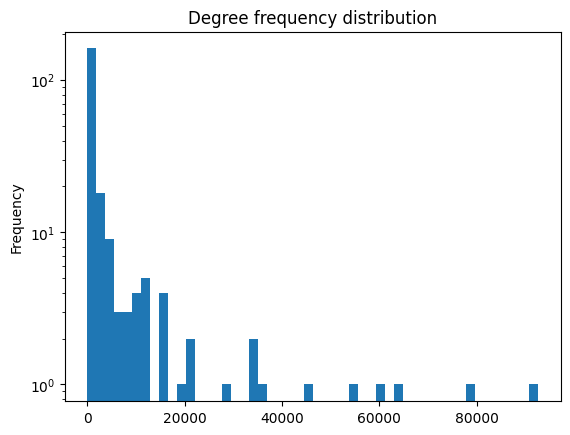

In [ ]:
degree_counts = high_school_analysis_df['degree'].value_counts()

# 1. Sort degrees by frequency
degree_counts_sorted = degree_counts.sort_values(ascending=False)

# 2. Plot distribution
degree_counts_sorted.plot(kind="hist", bins=50, log=True, title="Degree frequency distribution")

# 3. Cumulative coverage
cumulative_coverage = degree_counts_sorted.cumsum() / degree_counts_sorted.sum()

# 4. Find threshold: e.g. keep degrees that cover 90% of students
cutoff_index = cumulative_coverage[cumulative_coverage <= 0.90].index
degrees_to_keep = degree_counts_sorted.loc[cutoff_index].index

# 5. Define cutoff by minimum count
min_count = degree_counts_sorted.loc[cutoff_index].min()
print("Suggested cutoff:", min_count)


In [ ]:
# Find degrees with at least 3804 occurrences
valid_degrees = high_school_analysis_df['degree'].value_counts()[high_school_analysis_df['degree'].value_counts() >= 3596].index

# Filter the dataframe to keep only rows with valid degrees
high_school_analysis_df = high_school_analysis_df[high_school_analysis_df['degree'].isin(valid_degrees)].copy()
high_school_analysis_df['degree'].value_counts()

,count
degree,
BUSINESS MANAGEMENT,92577
LAW,79515
INDUSTRIAL ENGINEERING,64623
ACCOUNTING,60574
PSYCHOLOGY,53782
EDUCATION,45629
ENVIRONMENTAL STUDIES,35741
CIVIL ENGINEERING,34094
MEDICINE,34080


## Degree Focus Analysis

In [ ]:
high_school_analysis_df['degree.focus'].unique()

array(['ECONOMY', 'MANAGEMENT', 'PSYCHOLOGY', 'PUBLIC ACCOUNTING',
       'SOCIAL COMMUNICATION, JOURNALISM AND RELATED',
       'SYSTEMS ENGINEERING, TELEMATICS AND RELATED', 'LAW AND RELATED',
       'EDUCATION', 'ADMINISTRATIVE AND RELATED ENGINEERING',
       'ARCHITECTURE', 'DESIGN',
       'POLITICAL SCIENCE AND INTERNATIONAL RELATIONS',
       'MODERN LANGUAGES, LITERATURE, LINGUISTIC AND RELATED',
       'SOCIOLOGY, SOCIAL WORK AND RELATED', 'ADVERTISING AND RELATED',
       'ODONTOLOGY', 'MINING, METALLURGY AND RELATED ENGINEERING',
       'ENVIRONMENTAL, SANITARY AND RELATED ENGINEERING',
       'INDUSTRIAL AND RELATED ENGINEERING',
       'MECHANICAL AND RELATED ENGINEERING',
       'CIVIL ENGINEERING AND RELATED', 'NURSING',
       'PLASTIC, VISUAL AND RELATED ARTS', 'MUSIC',
       'MATHEMATICS, STATISTICS AND RELATED', 'THERAPIES',
       'CHEMICAL AND RELATED ENGINEERING', 'CHEMISTRY AND RELATED',
       'OTHER ENGINEERING', 'BACTERIOLOGY',
       'AGRONOMICAL, LIVESTOCK

In [ ]:
high_school_analysis_df['degree.focus'].value_counts()

,count
degree.focus,
MANAGEMENT,138128
LAW AND RELATED,81353
EDUCATION,73120
PUBLIC ACCOUNTING,60131
INDUSTRIAL AND RELATED ENGINEERING,53144
PSYCHOLOGY,51799
CIVIL ENGINEERING AND RELATED,33901
ECONOMY,32754
"SOCIAL COMMUNICATION, JOURNALISM AND RELATED",31907


In [ ]:
# Drop rows with 'TRAINING RELATED TO THE MILITARY OR POLICE FIELD' as degree category
high_school_analysis_df = high_school_analysis_df[high_school_analysis_df['degree.focus'] != 'TRAINING RELATED TO THE MILITARY OR POLICE FIELD'].copy()

In [ ]:
# Define a clear and concise mapping from degree focuses to broader categories
degree_category_map = {
    # Business & Economics
    'ECONOMY': 'Business & Economics',
    'MANAGEMENT': 'Business & Economics',
    'PUBLIC ACCOUNTING': 'Business & Economics',
    'ADVERTISING AND RELATED': 'Business & Economics',

    # Engineering & Technology
    'SYSTEMS ENGINEERING, TELEMATICS AND RELATED': 'Engineering & Technology',
    'ELECTRONIC ENGINEERING, TELECOMMUNICATIONS AND RELATED': 'Engineering & Technology',
    'ADMINISTRATIVE AND RELATED ENGINEERING': 'Engineering & Technology',
    'ARCHITECTURE': 'Engineering & Technology',
    'BIOMEDICAL AND RELATED ENGINEERING': 'Engineering & Technology',
    'MINING, METALLURGY AND RELATED ENGINEERING': 'Engineering & Technology',
    'ENVIRONMENTAL, SANITARY AND RELATED ENGINEERING': 'Engineering & Technology',
    'INDUSTRIAL AND RELATED ENGINEERING': 'Engineering & Technology',
    'MECHANICAL AND RELATED ENGINEERING': 'Engineering & Technology',
    'CIVIL ENGINEERING AND RELATED': 'Engineering & Technology',
    'ELECTRICAL AND RELATED ENGINEERING': 'Engineering & Technology',
    'OTHER ENGINEERING': 'Engineering & Technology',
    'CHEMICAL AND RELATED ENGINEERING': 'Engineering & Technology',

    # Arts, Humanities & Social Sciences
    'PSYCHOLOGY': 'Arts, Humanities & Social Sciences',
    'SOCIAL COMMUNICATION, JOURNALISM AND RELATED': 'Arts, Humanities & Social Sciences',
    'LAW AND RELATED': 'Arts, Humanities & Social Sciences',
    'DESIGN': 'Arts, Humanities & Social Sciences',
    'ANTHROPOLOGY AND LIBERAL ARTS': 'Arts, Humanities & Social Sciences',
    'POLITICAL SCIENCE AND INTERNATIONAL RELATIONS': 'Arts, Humanities & Social Sciences',
    'MODERN LANGUAGES, LITERATURE, LINGUISTIC AND RELATED': 'Arts, Humanities & Social Sciences',
    'SOCIOLOGY, SOCIAL WORK AND RELATED': 'Arts, Humanities & Social Sciences',
    'PLASTIC, VISUAL AND RELATED ARTS': 'Arts, Humanities & Social Sciences',
    'MUSIC': 'Arts, Humanities & Social Sciences',
    'PHILOSOPHY, THEOLOGY AND RELATED': 'Arts, Humanities & Social Sciences',
    'GEOGRAPHY AND HISTORY': 'Arts, Humanities & Social Sciences',
    'SPORTS, PHYSICAL EDUCATION AND RECREATION': 'Arts, Humanities & Social Sciences',
    'PERFORMING ARTS': 'Arts, Humanities & Social Sciences',
    'BIBLIOTECOLOGY, OTHER SOCIAL AND HUMAN SCIENCES': 'Arts, Humanities & Social Sciences',
    'OTHER PROGRAMS ASSOCIATED WITH FINE ARTS': 'Arts, Humanities & Social Sciences',

    # Natural Sciences
    'ZOOTECHNICS': 'Natural Sciences',
    'MATHEMATICS, STATISTICS AND RELATED': 'Natural Sciences',
    'CHEMISTRY AND RELATED': 'Natural Sciences',
    'BIOLOGY, MICROBIOLOGY AND RELATED': 'Natural Sciences',
    'PHYSICS': 'Natural Sciences',
    'GEOLOGY AND OTHER NATURAL SCIENCE PROGRAMS': 'Natural Sciences',

    # Environmental Sciences
    'AGRICULTURAL, FORESTRY AND RELATED ENGINEERING': 'Engineering & Technology',
    'AGRONOMICAL, LIVESTOCK AND RELATED ENGINERING': 'Engineering & Technology',
    'AGRONOMY': 'Natural Sciences',
    'AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING': 'Engineering & Technology',


    # Health Sciences
    'ODONTOLOGY': 'Health Sciences',
    'NURSING': 'Health Sciences',
    'THERAPIES': 'Health Sciences',
    'BACTERIOLOGY': 'Health Sciences',
    'MEDICINE': 'Health Sciences',
    'NUTRITION AND DIET': 'Health Sciences',
    'SURGICAL INSTRUMENTATION': 'Health Sciences',
    'VETERINARY MEDICINE': 'Health Sciences',
    'OPTOMETRY AND OTHER HEALTH SCIENCES PROGRAMS': 'Health Sciences',
    'PUBLIC HEALTH': 'Health Sciences',

    # Education
    'EDUCATION': 'Education',


}

# Function to map degree to category, fallback to 'Other' if not found
def map_degree_category(degree):
    """Maps a specific degree focus to its broader category."""
    return degree_category_map.get(degree, 'Other')

## Degree Category Mapping

In [ ]:
# degree_focus_mapper.py

import pandas as pd

# --- Mapping dictionary according to your proposals ---

degree_focus_mapping = {
    # 2) Health & Clinical Sciences
    "MEDICINE": "HEALTH & CLINICAL SCIENCES",
    "NURSING": "HEALTH & CLINICAL SCIENCES",
    "PUBLIC HEALTH": "HEALTH & CLINICAL SCIENCES",
    "THERAPIES": "HEALTH & CLINICAL SCIENCES",
    "SURGICAL INSTRUMENTATION": "HEALTH & CLINICAL SCIENCES",
    "ODONTOLOGY": "HEALTH & CLINICAL SCIENCES",
    "OPTOMETRY AND OTHER HEALTH SCIENCES PROGRAMS": "HEALTH & CLINICAL SCIENCES",
    "NUTRITION AND DIET": "HEALTH & CLINICAL SCIENCES",
    "BACTERIOLOGY": "HEALTH & CLINICAL SCIENCES",
    "VETERINARY MEDICINE": "HEALTH & CLINICAL SCIENCES",

    # 3a) Engineering Groups
    "CIVIL ENGINEERING AND RELATED": "CORE ENGINEERING",
    "MECHANICAL AND RELATED ENGINEERING": "CORE ENGINEERING",
    "INDUSTRIAL AND RELATED ENGINEERING": "CORE ENGINEERING",
    "ADMINISTRATIVE AND RELATED ENGINEERING": "CORE ENGINEERING",

    "ELECTRONIC ENGINEERING, TELECOMMUNICATIONS AND RELATED": "ELECTRICAL & ELECTRONICS ENGINEERING",
    "ELECTRICAL AND RELATED ENGINEERING": "ELECTRICAL & ELECTRONICS ENGINEERING",

    "MINING, METALLURGY AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "CHEMICAL AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "BIOMEDICAL AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "OTHER ENGINEERING": "SPECIALIZED ENGINEERING",

    # 4) Business & Management
    "MANAGEMENT": "BUSINESS & MANAGEMENT",
    "PUBLIC ACCOUNTING": "BUSINESS & MANAGEMENT",
    "ECONOMY": "BUSINESS & MANAGEMENT",

    # 5) Arts & Design
    "DESIGN": "ARTS & DESIGN",
    "PLASTIC, VISUAL AND RELATED ARTS": "ARTS & DESIGN",
    "PERFORMING ARTS": "ARTS & DESIGN",
    "MUSIC": "ARTS & DESIGN",
    "OTHER PROGRAMS ASSOCIATED WITH FINE ARTS": "ARTS & DESIGN",

    # 6) Social Sciences & Humanities
    "SOCIOLOGY, SOCIAL WORK AND RELATED": "SOCIAL SCIENCES & HUMANITIES",
    "POLITICAL SCIENCE AND INTERNATIONAL RELATIONS": "SOCIAL SCIENCES & HUMANITIES",
    "ANTHROPOLOGY AND LIBERAL ARTS": "SOCIAL SCIENCES & HUMANITIES",
    "GEOGRAPHY AND HISTORY": "SOCIAL SCIENCES & HUMANITIES",
    "PHILOSOPHY, THEOLOGY AND RELATED": "SOCIAL SCIENCES & HUMANITIES",
    "MODERN LANGUAGES, LITERATURE, LINGUISTIC AND RELATED": "SOCIAL SCIENCES & HUMANITIES",

    # 7) Natural & Basic Sciences
    "BIOLOGY, MICROBIOLOGY AND RELATED": "NATURAL & BASIC SCIENCES",
    "CHEMISTRY AND RELATED": "NATURAL & BASIC SCIENCES",
    "PHYSICS": "NATURAL & BASIC SCIENCES",
    "GEOLOGY AND OTHER NATURAL SCIENCE PROGRAMS": "NATURAL & BASIC SCIENCES",
    "MATHEMATICS, STATISTICS AND RELATED": "NATURAL & BASIC SCIENCES",

    # 8) Agricultural & Environmental
    "AGRONOMY": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "AGRICULTURAL, FORESTRY AND RELATED ENGINEERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "AGRONOMICAL, LIVESTOCK AND RELATED ENGINERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "ZOOTECHNICS": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "ENVIRONMENTAL, SANITARY AND RELATED ENGINEERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
}


# --- Function to apply mapping ---

def group_degree_focus(focus):
    """
    Maps a single degree focus or a pandas Series of focuses
    to grouped categories. Unmapped values go to 'OTHER / SPECIALIZED PROGRAMS'.
    """
    if isinstance(focus, pd.Series):
        return focus.map(lambda x: degree_focus_mapping.get(x, "OTHER / SPECIALIZED PROGRAMS"))
    elif isinstance(focus, list):
        return [degree_focus_mapping.get(x, "OTHER / SPECIALIZED PROGRAMS") for x in focus]
    else:
        return degree_focus_mapping.get(focus, "OTHER / SPECIALIZED PROGRAMS")


In [ ]:
high_school_analysis_df['degree.category'] = group_degree_focus(high_school_analysis_df['degree.focus'])

In [ ]:
high_school_analysis_df['degree.category'].value_counts()

,count
degree.category,
OTHER / SPECIALIZED PROGRAMS,288894
BUSINESS & MANAGEMENT,231013
CORE ENGINEERING,104691
HEALTH & CLINICAL SCIENCES,88508
AGRICULTURE & ENVIRONMENTAL SCIENCES,33957
SOCIAL SCIENCES & HUMANITIES,30419
ARTS & DESIGN,24789
ELECTRICAL & ELECTRONICS ENGINEERING,15893
NATURAL & BASIC SCIENCES,15287


# Cleaning

## Standardizing Numeric Columns

In [ ]:
# Ensure numeric columns are within 0-100 range
for col in numeric_columns:
    high_school_analysis_df = high_school_analysis_df[(high_school_analysis_df[col] >= 0) & (high_school_analysis_df[col] <= 100)]

## Handling Nulls

In [ ]:
high_school_analysis_df.isnull().sum()

,0
ENG.HS,0
SC.HS,0
MATH.HS,0
CR.HS,0
NS.HS,0
degree,0
degree.focus,0
gender,498
fefu,594309
femu,592788


Text(0.5, 1.0, 'Missing Values Heatmap')

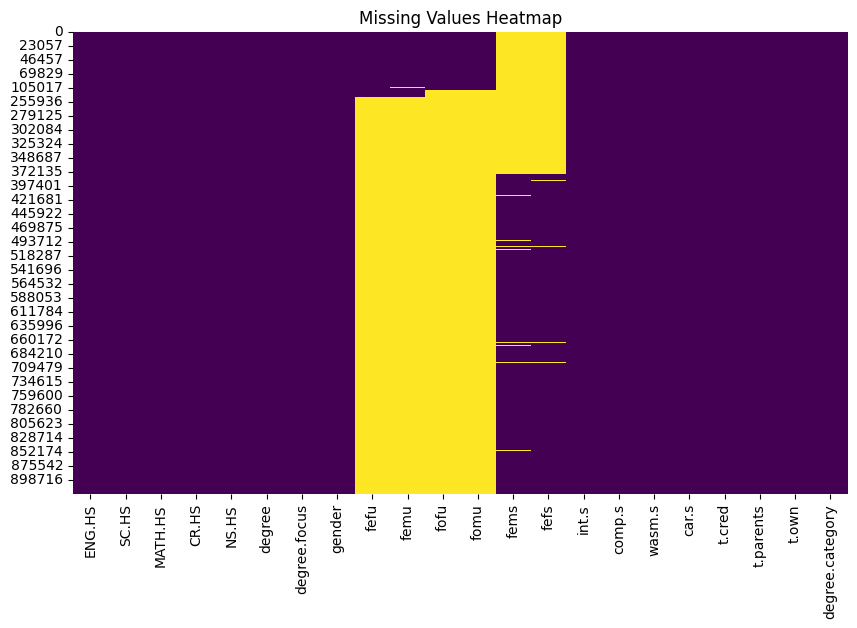

In [ ]:
# Missing Map
plt.figure(figsize=(10,6))
sns.heatmap(high_school_analysis_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')

In [ ]:
high_school_analysis_df['fefs'].unique()

array([nan, 'primary school complete', 'complete professional education',
       'incomplete primary school', 'incomplete secondary school',
       'complete secondary school', 'Incomplete professional education',
       'complete Technical degree', 'Does not know', 'Postgraduate',
       'incomplete technical degree', 'does not apply'], dtype=object)

In [ ]:
high_school_analysis_df['fems'].unique()


array([nan, 'incomplete primary school', 'incomplete secondary school',
       'complete professional education', 'primary school complete',
       'complete secondary school', 'Does not know',
       'Incomplete professional education', 'complete Technical degree',
       'Postgraduate', 'incomplete technical degree', 'does not apply'],
      dtype=object)

In [ ]:
high_school_analysis_df['fefu'].unique()

array(['incomplete primary school', 'complete Technical degree',
       'complete professional education', 'primary school complete',
       'incomplete secondary school', 'Incomplete professional education',
       'complete secondary school', 'Postgraduate',
       'incomplete technical degree', nan, 'Does not know',
       'does not apply'], dtype=object)

In [ ]:
high_school_analysis_df['femu'].unique()


array(['complete professional education', 'complete secondary school',
       'Postgraduate', 'primary school complete',
       'incomplete secondary school', 'incomplete primary school',
       'complete Technical degree', nan,
       'Incomplete professional education', 'incomplete technical degree',
       'Does not know', 'does not apply'], dtype=object)

In [ ]:
high_school_analysis_df['fofu'].unique()

array(['Independent professional', 'worker employee and operator',
       'Stay-at-home dad', 'Little Businessman', 'executive director',
       'Self-employed', 'Other activity or occupation',
       'Technical or professional level employee', 'Pensionado',
       'general manager', 'businessman', 'auxiliary level employee',
       'unemployed', 'does not apply', 'worker or government employee',
       'Worker or employee of a private company', 'employer',
       'Domestic employee', 'day laborer', 'Unpaid family worker',
       'Trabajador sin remuneración en empresas o negocios de otros hogares',
       nan], dtype=object)

In [ ]:
high_school_analysis_df['fomu'].unique()

array(['Independent professional', 'Stay-at-home dad', 'Pensionado',
       'Technical or professional level employee',
       'worker employee and operator', 'auxiliary level employee',
       'executive director', 'Other activity or occupation',
       'businessman', 'general manager', 'Self-employed',
       'Little Businessman', 'unemployed', 'Domestic employee',
       'worker or government employee', 'does not apply',
       'Unpaid family worker', 'Worker or employee of a private company',
       'employer', 'Worker without remuneration', 'day laborer', nan],
      dtype=object)

fefs, fems and fefu, femu seem to have the same data in them (Likely data on the respective education levels of their parents). these 2 pairs are also never not null at the same time and thus I must pick one of them to use at a time. As such I will create 2 datasets, 1 using fefs and fems along with the accademic data (this is a larger dataset), and  a second with fefu and femu with fomu and fofu, and academic data, which is a smaller dataset but has more features.

In [ ]:
education_only_df = high_school_analysis_df.drop(columns=['fefu', 'femu', 'fofu', 'fomu'])
education_only_df = education_only_df.dropna()
education_only_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466390 entries, 375787 to 943009
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ENG.HS           466390 non-null  float64
 1   SC.HS            466390 non-null  float64
 2   MATH.HS          466390 non-null  float64
 3   CR.HS            466390 non-null  float64
 4   NS.HS            466390 non-null  float64
 5   degree           466390 non-null  object 
 6   degree.focus     466390 non-null  object 
 7   gender           466390 non-null  object 
 8   fems             466390 non-null  object 
 9   fefs             466390 non-null  object 
 10  int.s            466390 non-null  float64
 11  comp.s           466390 non-null  float64
 12  wasm.s           466390 non-null  float64
 13  car.s            466390 non-null  float64
 14  t.cred           466390 non-null  int64  
 15  t.parents        466390 non-null  int64  
 16  t.own            466390 non-null  int6

In [ ]:
education_only_df.isnull().sum()

,0
ENG.HS,0
SC.HS,0
MATH.HS,0
CR.HS,0
NS.HS,0
degree,0
degree.focus,0
gender,0
fems,0
fefs,0


In [ ]:
education_only_df['fefs'].unique()

array(['primary school complete', 'complete professional education',
       'incomplete primary school', 'incomplete secondary school',
       'complete secondary school', 'Incomplete professional education',
       'Does not know', 'complete Technical degree', 'Postgraduate',
       'incomplete technical degree', 'does not apply'], dtype=object)

In [ ]:
education_only_df['fems'].unique()

array(['incomplete primary school', 'incomplete secondary school',
       'complete professional education', 'primary school complete',
       'complete secondary school', 'Does not know',
       'Incomplete professional education', 'complete Technical degree',
       'Postgraduate', 'incomplete technical degree', 'does not apply'],
      dtype=object)

In [ ]:
education_only_df['fems'] = education_only_df['fems'].str.lower()
education_only_df['fefs'] = education_only_df['fefs'].str.lower()

In [ ]:
education_only_df.to_csv('/content/drive/My Drive/IS_II/datasets/education_only_data.csv', index=False)

In [ ]:
education_and_occupation_df = high_school_analysis_df.drop(columns=['fefs', 'fems'])
education_and_occupation_df = education_and_occupation_df.dropna()
education_and_occupation_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83488 entries, 0 to 108688
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ENG.HS           83488 non-null  float64
 1   SC.HS            83488 non-null  float64
 2   MATH.HS          83488 non-null  float64
 3   CR.HS            83488 non-null  float64
 4   NS.HS            83488 non-null  float64
 5   degree           83488 non-null  object 
 6   degree.focus     83488 non-null  object 
 7   gender           83488 non-null  object 
 8   fefu             83488 non-null  object 
 9   femu             83488 non-null  object 
 10  fofu             83488 non-null  object 
 11  fomu             83488 non-null  object 
 12  int.s            83488 non-null  float64
 13  comp.s           83488 non-null  float64
 14  wasm.s           83488 non-null  float64
 15  car.s            83488 non-null  float64
 16  t.cred           83488 non-null  int64  
 17  t.parents       

In [ ]:
education_and_occupation_df.isnull().sum()

,0
ENG.HS,0
SC.HS,0
MATH.HS,0
CR.HS,0
NS.HS,0
degree,0
degree.focus,0
gender,0
fefu,0
femu,0


In [ ]:
education_and_occupation_df.to_csv('/content/drive/My Drive/IS_II/datasets/education_and_occupation_data.csv', index=False)